# Healthcare Appointment No-Show Prediction

## Project Objective

The objective of this project is to analyze healthcare appointment
data and predict whether a patient will attend or miss a scheduled
appointment.

The project will identify important factors associated with
appointment no-shows and develop a machine learning model that
assigns a no-show risk score to appointments.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Power BI

## Project Workflow

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Machine Learning
7. Model Evaluation
8. Risk Prediction
9. Power BI Dashboard
10. Business Recommendations

## Project Information

**Project Type:** Machine Learning Classification

**Domain:** Healthcare Analytics

**Target Variable:** Appointment No-Show

**Prediction:**
- 0 = Patient attended
- 1 = Patient did not attend

**Primary Goal:**
Predict appointments that are at high risk of being missed.

# 1. Data Loading

In this section, the healthcare appointment dataset will be loaded
into Python using Pandas.

The original dataset is stored in the `data/raw` folder so that the
raw data remains unchanged.

In [4]:
import pandas as pd

In [12]:
import os

project_path = r"C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show"

print(project_path)

C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show


In [13]:
raw_data_path = os.path.join(
    project_path,
    "data",
    "raw",
    "noshowappointments-kagglev2-may-2016.csv"
)

print(raw_data_path)

C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\raw\noshowappointments-kagglev2-may-2016.csv


In [14]:
print(os.path.exists(raw_data_path))

True


In [15]:
print(os.listdir(
    os.path.join(project_path, "data", "raw")
))

['noshowappointments-kagglev2-may-2016.csv']


In [16]:
df = pd.read_csv(raw_data_path)

In [17]:
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [18]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 110527
Columns: 14


In [22]:
#first five records.
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [23]:
#last 5 rows
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,2.572130e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596270e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557660e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213490e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,3.775120e+14,5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


In [24]:
#Check the column names
print(df.columns.tolist())

['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


In [25]:
df.shape

(110527, 14)

# 2. Data Understanding and Data Quality Check

In this section, the structure, data types, missing values,
duplicates, unique values and potential data-quality issues
in the healthcare appointment dataset will be examined.

In [26]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 110527
Number of columns: 14


In [27]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


In [28]:
for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

1 - PatientId
2 - AppointmentID
3 - Gender
4 - ScheduledDay
5 - AppointmentDay
6 - Age
7 - Neighbourhood
8 - Scholarship
9 - Hipertension
10 - Diabetes
11 - Alcoholism
12 - Handcap
13 - SMS_received
14 - No-show


In [29]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [31]:
print(df.dtypes)

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [32]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [33]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100)

print(missing_percentage)

PatientId         0.0
AppointmentID     0.0
Gender            0.0
ScheduledDay      0.0
AppointmentDay    0.0
Age               0.0
Neighbourhood     0.0
Scholarship       0.0
Hipertension      0.0
Diabetes          0.0
Alcoholism        0.0
Handcap           0.0
SMS_received      0.0
No-show           0.0
dtype: float64


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["AppointmentID"].duplicated().sum()

np.int64(0)

In [36]:
df["PatientId"].nunique()

61744

In [37]:
df["AppointmentID"].nunique()

110527

In [38]:
df["Gender"].value_counts()

Gender
F    71840
M    38687
Name: count, dtype: int64

In [39]:
df["Neighbourhood"].nunique()

81

In [40]:
df["Neighbourhood"].value_counts().head(10)

Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64

In [41]:
df["Scholarship"].value_counts()

Scholarship
0    99666
1    10861
Name: count, dtype: int64

In [42]:
print("Hypertension:")
print(df["Hipertension"].value_counts())

print("\nDiabetes:")
print(df["Diabetes"].value_counts())

print("\nAlcoholism:")
print(df["Alcoholism"].value_counts())

print("\nHandicap:")
print(df["Handcap"].value_counts())

Hypertension:
Hipertension
0    88726
1    21801
Name: count, dtype: int64

Diabetes:
Diabetes
0    102584
1      7943
Name: count, dtype: int64

Alcoholism:
Alcoholism
0    107167
1      3360
Name: count, dtype: int64

Handicap:
Handcap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


In [43]:
df["SMS_received"].value_counts()

SMS_received
0    75045
1    35482
Name: count, dtype: int64

In [44]:
df["No-show"].value_counts()

No-show
No     88208
Yes    22319
Name: count, dtype: int64

In [45]:
df["No-show"].value_counts(normalize=True) * 100

No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

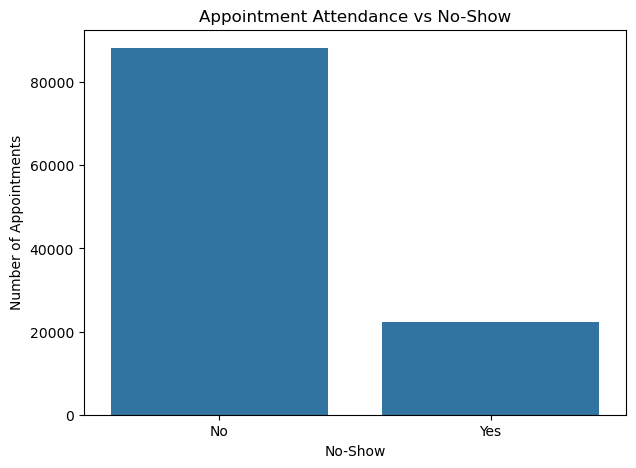

In [47]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="No-show"
)

plt.title("Appointment Attendance vs No-Show")
plt.xlabel("No-Show")
plt.ylabel("Number of Appointments")

plt.show()

In [48]:
df["Age"].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [49]:
(df["Age"] < 0).sum()

np.int64(1)

In [50]:
df[df["Age"] > 100]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
58014,9.762950e+14,5651757,F,2016-05-03T09:14:53Z,2016-05-03T00:00:00Z,102,CONQUISTA,0,0,0,0,0,0,No
63912,3.196320e+13,5700278,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
63915,3.196320e+13,5700279,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
68127,3.196320e+13,5562812,F,2016-04-08T14:29:17Z,2016-05-16T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
76284,3.196320e+13,5744037,F,2016-05-30T09:44:51Z,2016-05-30T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,No
90372,2.342840e+11,5751563,F,2016-05-31T10:19:49Z,2016-06-02T00:00:00Z,102,MARIA ORTIZ,0,0,0,0,0,0,No
97666,7.482350e+14,5717451,F,2016-05-19T07:57:56Z,2016-06-03T00:00:00Z,115,SÃO JOSÉ,0,1,0,0,0,1,No


In [51]:
print(df["ScheduledDay"].head())
print(df["AppointmentDay"].head())

0    2016-04-29T18:38:08Z
1    2016-04-29T16:08:27Z
2    2016-04-29T16:19:04Z
3    2016-04-29T17:29:31Z
4    2016-04-29T16:07:23Z
Name: ScheduledDay, dtype: object
0    2016-04-29T00:00:00Z
1    2016-04-29T00:00:00Z
2    2016-04-29T00:00:00Z
3    2016-04-29T00:00:00Z
4    2016-04-29T00:00:00Z
Name: AppointmentDay, dtype: object


In [52]:
print("ScheduledDay:", df["ScheduledDay"].dtype)
print("AppointmentDay:", df["AppointmentDay"].dtype)

ScheduledDay: object
AppointmentDay: object


In [53]:
scheduled_temp = pd.to_datetime(
    df["ScheduledDay"]
)

appointment_temp = pd.to_datetime(
    df["AppointmentDay"]
)

In [54]:
date_check = appointment_temp < scheduled_temp

print(
    "Appointments before scheduling:",
    date_check.sum()
)

Appointments before scheduling: 38568


In [55]:
data_quality_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_quality_summary

,Column,Data Type,Missing Values,Unique Values
0,PatientId,float64,0,61744
1,AppointmentID,int64,0,110527
2,Gender,object,0,2
3,ScheduledDay,object,0,103549
4,AppointmentDay,object,0,27
5,Age,int64,0,104
6,Neighbourhood,object,0,81
7,Scholarship,int64,0,2
8,Hipertension,int64,0,2
9,Diabetes,int64,0,2


In [56]:
len(df)

110527

In [57]:
len(df.columns)

14

# 3. Data Cleaning

In this section, the dataset will be cleaned and prepared for
exploratory data analysis and machine learning.

The cleaning process includes standardizing column names,
correcting data types, handling invalid values, checking
duplicates, processing dates and preparing the target variable.

In [61]:
df_clean = df.copy()

In [59]:
print("Original dataset shape:", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Original dataset shape: (110527, 14)
Cleaning dataset shape: (110527, 14)


In [62]:
df_clean = df_clean.rename(columns={
    "PatientId": "patient_id",
    "AppointmentID": "appointment_id",
    "Gender": "gender",
    "ScheduledDay": "scheduled_date",
    "AppointmentDay": "appointment_date",
    "Age": "age",
    "Neighbourhood": "neighbourhood",
    "Scholarship": "scholarship",
    "Hipertension": "hypertension",
    "Diabetes": "diabetes",
    "Alcoholism": "alcoholism",
    "Handcap": "handicap",
    "SMS_received": "sms_received",
    "No-show": "no_show"
})

In [63]:
print(df_clean.columns.tolist())

['patient_id', 'appointment_id', 'gender', 'scheduled_date', 'appointment_date', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show']


In [64]:
df_clean.dtypes

patient_id          float64
appointment_id        int64
gender               object
scheduled_date       object
appointment_date     object
age                   int64
neighbourhood        object
scholarship           int64
hypertension          int64
diabetes              int64
alcoholism            int64
handicap              int64
sms_received          int64
no_show              object
dtype: object

In [65]:
df_clean["scheduled_date"] = pd.to_datetime(
    df_clean["scheduled_date"]
)

In [66]:
df_clean["appointment_date"] = pd.to_datetime(
    df_clean["appointment_date"]
)

In [67]:
print(
    "Scheduled date:",
    df_clean["scheduled_date"].dtype
)

print(
    "Appointment date:",
    df_clean["appointment_date"].dtype
)

Scheduled date: datetime64[ns, UTC]
Appointment date: datetime64[ns, UTC]


In [68]:
invalid_dates = (
    df_clean["appointment_date"]
    < df_clean["scheduled_date"]
)

print(
    "Appointments before scheduled date:",
    invalid_dates.sum()
)

Appointments before scheduled date: 38568


In [69]:
print(
    "Invalid ages:",
    (df_clean["age"] < 0).sum()
)

Invalid ages: 1


In [70]:
df_clean = df_clean[
    df_clean["age"] >= 0
].copy()

In [71]:
print(
    "Invalid ages after cleaning:",
    (df_clean["age"] < 0).sum()
)

Invalid ages after cleaning: 0


In [72]:
print("Original rows:", len(df))
print("Rows after age cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 110527
Rows after age cleaning: 110526
Rows removed: 1


In [73]:
duplicate_rows = df_clean.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_rows
)

Duplicate rows: 0


In [74]:
print(
    "Duplicate rows after cleaning:",
    df_clean.duplicated().sum()
)

Duplicate rows after cleaning: 0


In [75]:
df_clean["appointment_id"].duplicated().sum()

np.int64(0)

In [76]:
duplicate_appointments = df_clean[
    df_clean["appointment_id"].duplicated(
        keep=False
    )
]

duplicate_appointments.head()

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show


In [77]:
df_clean["gender"].value_counts()

gender
F    71839
M    38687
Name: count, dtype: int64

In [78]:
binary_columns = [
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received"
]

for column in binary_columns:
    print("\n", column)
    print(df_clean[column].value_counts())


 scholarship
scholarship
0    99665
1    10861
Name: count, dtype: int64

 hypertension
hypertension
0    88725
1    21801
Name: count, dtype: int64

 diabetes
diabetes
0    102583
1      7943
Name: count, dtype: int64

 alcoholism
alcoholism
0    107166
1      3360
Name: count, dtype: int64

 handicap
handicap
0    108285
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

 sms_received
sms_received
0    75044
1    35482
Name: count, dtype: int64


In [79]:
df_clean["no_show"].value_counts()

no_show
No     88207
Yes    22319
Name: count, dtype: int64

In [80]:
df_clean["no_show_target"] = df_clean[
    "no_show"
].map({
    "No": 0,
    "Yes": 1
})

In [82]:
df_clean[
    ["no_show", "no_show_target"]
].value_counts()

no_show  no_show_target
No       0                 88207
Yes      1                 22319
Name: count, dtype: int64

In [83]:
df_clean["no_show_target"].isnull().sum()

np.int64(0)

In [101]:
df_clean["waiting_days"] = (
    df_clean["appointment_date"].dt.date
    - df_clean["scheduled_date"].dt.date
).apply(lambda x: x.days)

In [102]:
df_clean["waiting_days"].describe()

count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

In [103]:
print(
    "Negative waiting days:",
    (df_clean["waiting_days"] < 0).sum())

Negative waiting days: 5


In [104]:
df_clean["appointment_weekday"] = (
    df_clean["appointment_date"]
    .dt.day_name())

In [105]:
df_clean["appointment_weekday"].value_counts()

appointment_weekday
Wednesday    25867
Tuesday      25640
Monday       22714
Friday       19019
Thursday     17247
Saturday        39
Name: count, dtype: int64

In [106]:
df_clean["appointment_month"] = (
    df_clean["appointment_date"]
    .dt.month
)

In [107]:
df_clean["appointment_month"].value_counts().sort_index()

appointment_month
4     3235
5    80841
6    26450
Name: count, dtype: int64

In [108]:
print(
    "Cleaned dataset shape:",
    df_clean.shape
    
)

Cleaned dataset shape: (110526, 18)


In [109]:
df_clean.isnull().sum()

patient_id             0
appointment_id         0
gender                 0
scheduled_date         0
appointment_date       0
age                    0
neighbourhood          0
scholarship            0
hypertension           0
diabetes               0
alcoholism             0
handicap               0
sms_received           0
no_show                0
no_show_target         0
waiting_days           0
appointment_weekday    0
appointment_month      0
dtype: int64

In [110]:
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

print(
    "Duplicate appointment IDs:",
    df_clean["appointment_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate appointment IDs: 0


In [111]:
df_clean.dtypes

patient_id                         float64
appointment_id                       int64
gender                              object
scheduled_date         datetime64[ns, UTC]
appointment_date       datetime64[ns, UTC]
age                                  int64
neighbourhood                       object
scholarship                          int64
hypertension                         int64
diabetes                             int64
alcoholism                           int64
handicap                             int64
sms_received                         int64
no_show                             object
no_show_target                       int64
waiting_days                         int64
appointment_weekday                 object
appointment_month                    int32
dtype: object

In [112]:
df_clean.head()

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,no_show_target,waiting_days,appointment_weekday,appointment_month
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,0,Friday,4
1,5.589980e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,0,Friday,4
2,4.262960e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,0,Friday,4
3,8.679510e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,0,Friday,4
4,8.841190e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,0,Friday,4


In [113]:
cleaning_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": df_clean.dtypes.astype(str).values,
    "Missing Values": df_clean.isnull().sum().values,
    "Unique Values": df_clean.nunique().values
})

cleaning_summary

,Column,Data Type,Missing Values,Unique Values
0,patient_id,float64,0,61743
1,appointment_id,int64,0,110526
2,gender,object,0,2
3,scheduled_date,"datetime64[ns, UTC]",0,103548
4,appointment_date,"datetime64[ns, UTC]",0,27
5,age,int64,0,103
6,neighbourhood,object,0,81
7,scholarship,int64,0,2
8,hypertension,int64,0,2
9,diabetes,int64,0,2


In [114]:
cleaned_path = os.path.join(
    project_path,
    "data",
    "cleaned",
    "cleaned_appointments.csv"
)

print(cleaned_path)

C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\cleaned\cleaned_appointments.csv


In [115]:
df_clean.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(cleaned_path)

Cleaned dataset saved successfully!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\cleaned\cleaned_appointments.csv


In [117]:
print(os.path.exists(cleaned_path))

True


In [118]:
print(df_clean.shape)
print(df_clean.isnull().sum().sum())
print(df_clean.duplicated().sum())
print(df_clean["no_show_target"].value_counts())
print((df_clean["waiting_days"] < 0).sum())

(110526, 18)
0
0
no_show_target
0    88207
1    22319
Name: count, dtype: int64
5


In [119]:
df_clean[df_clean["waiting_days"] < 0][
    [
        "appointment_id",
        "scheduled_date",
        "appointment_date",
        "waiting_days",
        "no_show"
    ]
]

,appointment_id,scheduled_date,appointment_date,waiting_days,no_show
27033,5679978,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1,Yes
55226,5715660,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1,Yes
64175,5664962,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1,Yes
71533,5686628,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6,Yes
72362,5655637,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1,Yes


In [120]:
df_clean = df_clean[
    df_clean["waiting_days"] >= 0
].copy()

In [121]:
print(
    "Negative waiting days:",
    (df_clean["waiting_days"] < 0).sum()
)

Negative waiting days: 0


In [122]:
print("Rows after cleaning:", len(df_clean))

Rows after cleaning: 110521


In [123]:
print(
    "Total missing values:",
    df_clean.isnull().sum().sum()
)

Total missing values: 0


In [124]:
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

print(
    "Duplicate appointment IDs:",
    df_clean["appointment_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate appointment IDs: 0


In [125]:
print(
    df_clean["no_show_target"].value_counts()
)

no_show_target
0    88207
1    22314
Name: count, dtype: int64


In [126]:
print(
    df_clean["waiting_days"].describe()
)

count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64


In [127]:
print(
    "Negative waiting days:",
    (df_clean["waiting_days"] < 0).sum()
)

Negative waiting days: 0


In [128]:
df_clean.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset updated successfully!")
print(cleaned_path)

Cleaned dataset updated successfully!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\cleaned\cleaned_appointments.csv


In [129]:
print(os.path.exists(cleaned_path))

True


In [130]:
print("Final shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Negative waiting days:", (df_clean["waiting_days"] < 0).sum())
print("\nTarget distribution:")
print(df_clean["no_show_target"].value_counts())

Final shape: (110521, 18)
Missing values: 0
Duplicate rows: 0
Negative waiting days: 0

Target distribution:
no_show_target
0    88207
1    22314
Name: count, dtype: int64


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to identify patterns,
relationships and factors associated with healthcare appointment
no-shows.

The analysis focuses on patient characteristics, appointment
features, reminder information and waiting time.

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
plt.rcParams["figure.figsize"] = (8, 5)

In [133]:
df_clean.head()

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,no_show_target,waiting_days,appointment_weekday,appointment_month
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,0,Friday,4
1,5.589980e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,0,Friday,4
2,4.262960e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,0,Friday,4
3,8.679510e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,0,Friday,4
4,8.841190e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,0,Friday,4


In [134]:
df_clean.shape

(110521, 18)

## 4.1 Overall Appointment Attendance and No-Show Distribution

The distribution of attended and missed appointments is examined
to understand the target variable and identify class imbalance.

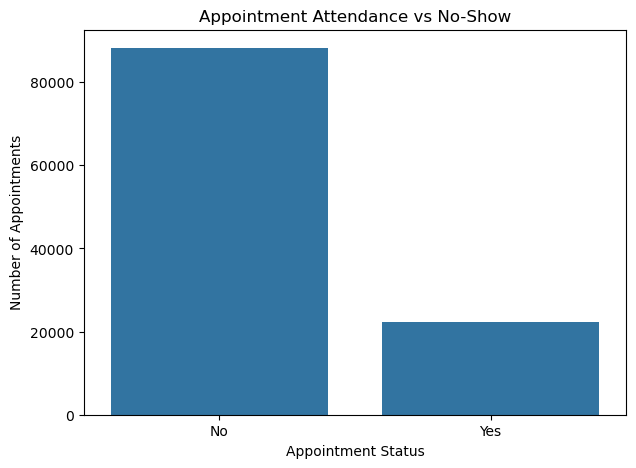

In [135]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="no_show"
)

plt.title("Appointment Attendance vs No-Show")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")

plt.show()

In [136]:
target_percentage = (
    df_clean["no_show"]
    .value_counts(normalize=True)
    * 100
)

print(target_percentage)

no_show
No     79.810172
Yes    20.189828
Name: proportion, dtype: float64


In [137]:
target_summary = pd.DataFrame({
    "Count": df_clean["no_show"].value_counts(),
    "Percentage": (
        df_clean["no_show"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
})

target_summary

,Count,Percentage
no_show,,
No,88207,79.81
Yes,22314,20.19


## 4.2 Gender-wise No-Show Analysis

The no-show rate is compared across genders to determine whether
appointment attendance differs between male and female patients.

In [138]:
df_clean["gender"].value_counts()

gender
F    71836
M    38685
Name: count, dtype: int64

In [139]:
gender_no_show = (
    df_clean
    .groupby("gender")["no_show_target"]
    .mean()
    * 100
)

gender_no_show

gender
F    20.311543
M    19.963810
Name: no_show_target, dtype: float64

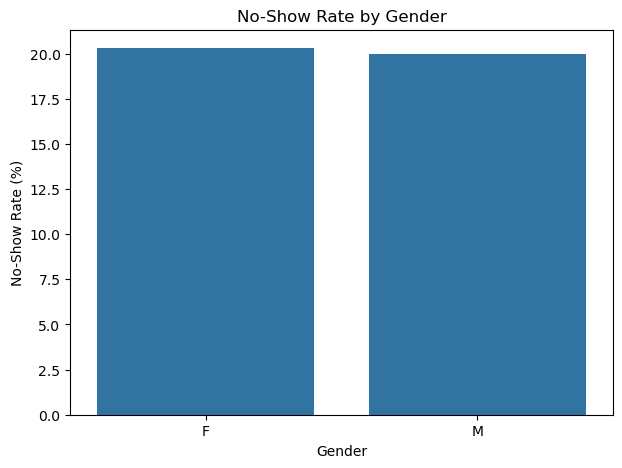

In [140]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_no_show.index,
    y=gender_no_show.values
)

plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")

plt.show()

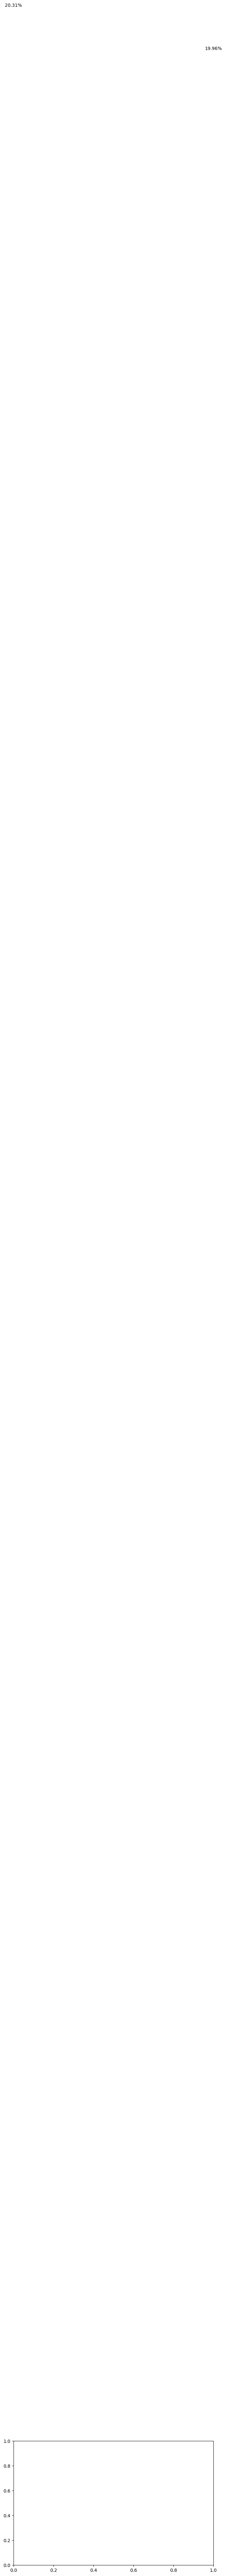

In [141]:
for i, value in enumerate(gender_no_show.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

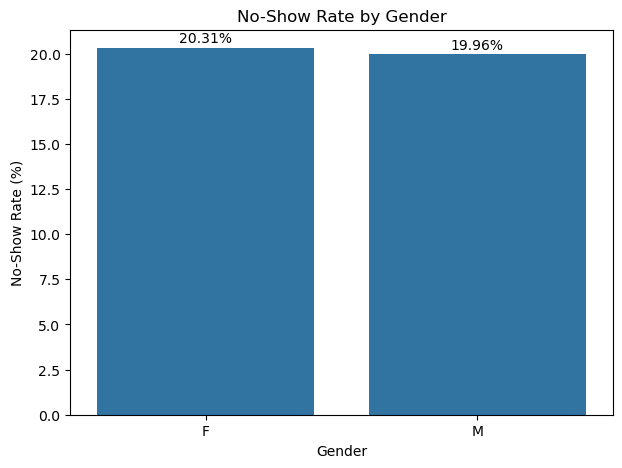

In [142]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=gender_no_show.index,
    y=gender_no_show.values
)

plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")

for i, value in enumerate(gender_no_show.values):
    ax.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

## 4.3 Age-wise No-Show Analysis

Age distribution and age-group-specific no-show rates are analyzed
to identify whether certain age groups are more likely to miss
appointments.

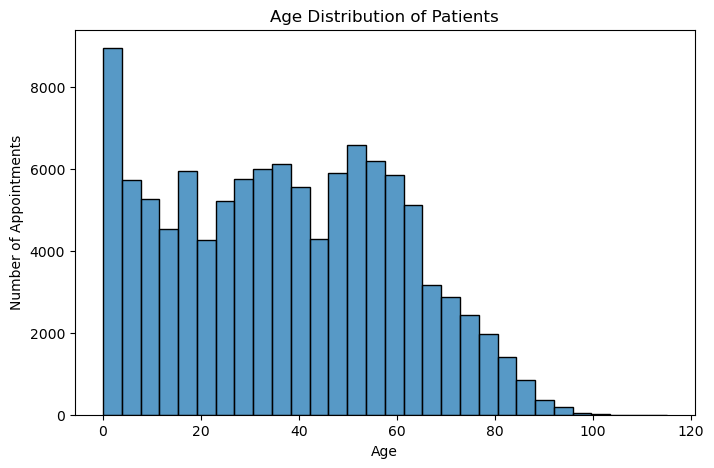

In [143]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Appointments")

plt.show()

In [144]:
bins = [0, 12, 18, 30, 45, 60, 75, 100]
labels = [
    "0-12",
    "13-18",
    "19-30",
    "31-45",
    "46-60",
    "61-75",
    "76-100"
]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [145]:
df_clean["age_group"].value_counts().sort_index()

age_group
0-12      21035
13-18      7830
19-30     16763
31-45     21953
46-60     23179
61-75     14370
76-100     5384
Name: count, dtype: int64

In [146]:
age_no_show = (
    df_clean
    .groupby("age_group", observed=True)["no_show_target"]
    .mean()
    * 100
)

age_no_show

age_group
0-12      20.470644
13-18     26.053640
19-30     24.703215
31-45     21.368378
46-60     17.822167
61-75     14.864301
76-100    16.084695
Name: no_show_target, dtype: float64

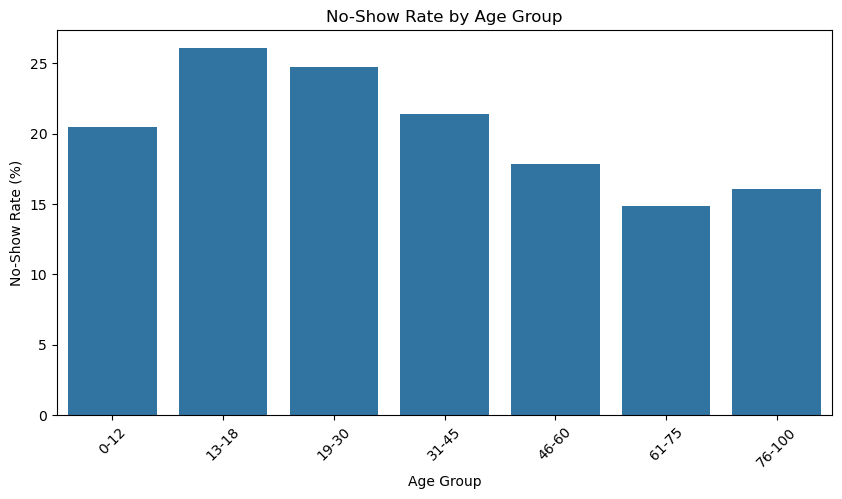

In [147]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_no_show.index,
    y=age_no_show.values
)

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")

plt.xticks(rotation=45)

plt.show()

## 4.4 SMS Reminder and No-Show Analysis

The relationship between SMS reminders and appointment no-shows
is analyzed to determine whether receiving an SMS reminder is
associated with appointment attendance.

In [148]:
df_clean["sms_received"].value_counts()

sms_received
0    75039
1    35482
Name: count, dtype: int64

In [149]:
sms_no_show = (
    df_clean
    .groupby("sms_received")["no_show_target"]
    .mean()
    * 100
)

sms_no_show

sms_received
0    16.697984
1    27.574545
Name: no_show_target, dtype: float64

In [150]:
sms_labels = {
    0: "No SMS",
    1: "SMS Received"
}

sms_no_show.index = sms_no_show.index.map(sms_labels)


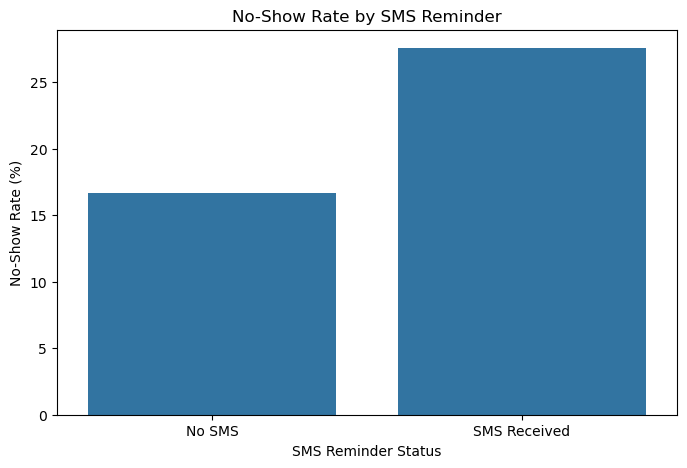

In [151]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sms_no_show.index,
    y=sms_no_show.values
)

plt.title("No-Show Rate by SMS Reminder")
plt.xlabel("SMS Reminder Status")
plt.ylabel("No-Show Rate (%)")

plt.show()

## 4.5 Waiting Time and No-Show Analysis

The relationship between the number of days between appointment
scheduling and the appointment date is analyzed to determine
whether longer waiting periods are associated with higher
no-show rates

In [152]:
df_clean["waiting_days"].describe()

count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

In [153]:
waiting_bins = [-1, 0, 3, 7, 14, 30, 60, 365]
waiting_labels = [
    "Same day",
    "1-3 days",
    "4-7 days",
    "8-14 days",
    "15-30 days",
    "31-60 days",
    "61+ days"
]

df_clean["waiting_group"] = pd.cut(
    df_clean["waiting_days"],
    bins=waiting_bins,
    labels=waiting_labels
)

In [154]:
df_clean["waiting_group"].value_counts().sort_index()

waiting_group
Same day      38562
1-3 days      14675
4-7 days      17510
8-14 days     12025
15-30 days    17371
31-60 days     8283
61+ days       2095
Name: count, dtype: int64

In [155]:
waiting_no_show = (
    df_clean
    .groupby(
        "waiting_group",
        observed=True
    )["no_show_target"]
    .mean()
    * 100
)

waiting_no_show

waiting_group
Same day       4.647062
1-3 days      22.889267
4-7 days      25.202741
8-14 days     30.469854
15-30 days    32.588797
31-60 days    34.154292
61+ days      28.448687
Name: no_show_target, dtype: float64

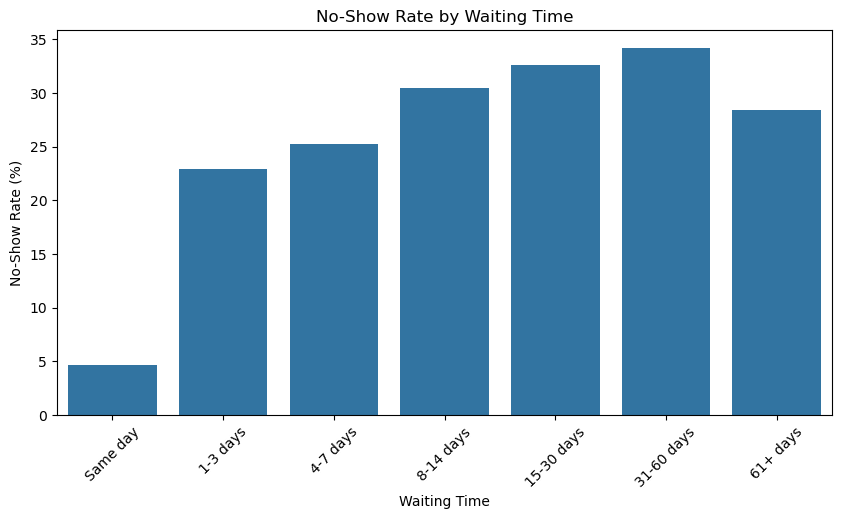

In [156]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=waiting_no_show.index,
    y=waiting_no_show.values
)

plt.title("No-Show Rate by Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("No-Show Rate (%)")

plt.xticks(rotation=45)

plt.show()

## 4.6 Appointment Weekday Analysis

No-show rates are analyzed across different days of the week
to identify potential weekday patterns in appointment attendance.

In [157]:
weekday_no_show = (
    df_clean
    .groupby(
        "appointment_weekday"
    )["no_show_target"]
    .mean()
    * 100
)

In [158]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_no_show = weekday_no_show.reindex(
    weekday_order
)

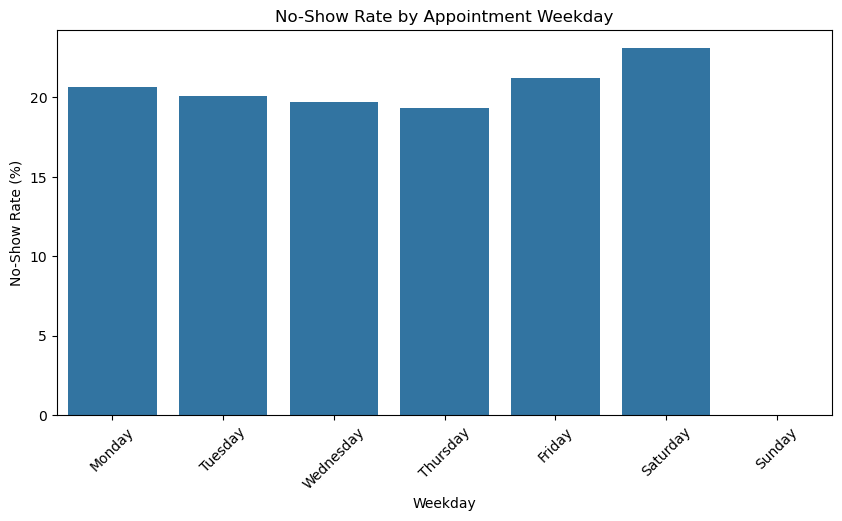

In [159]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_no_show.index,
    y=weekday_no_show.values
)

plt.title("No-Show Rate by Appointment Weekday")
plt.xlabel("Weekday")
plt.ylabel("No-Show Rate (%)")

plt.xticks(rotation=45)

plt.show()

## 4.7 Scholarship and No-Show Analysis

The relationship between scholarship status and appointment
no-shows is analyzed to determine whether attendance patterns
differ between patients with and without scholarship support.

In [160]:
scholarship_no_show = (
    df_clean
    .groupby("scholarship")["no_show_target"]
    .mean()
    * 100
)

scholarship_no_show

scholarship
0    19.803331
1    23.736304
Name: no_show_target, dtype: float64

In [161]:
scholarship_labels = {
    0: "No Scholarship",
    1: "Scholarship"
}

scholarship_no_show.index = (
    scholarship_no_show.index.map(
        scholarship_labels
    )
)

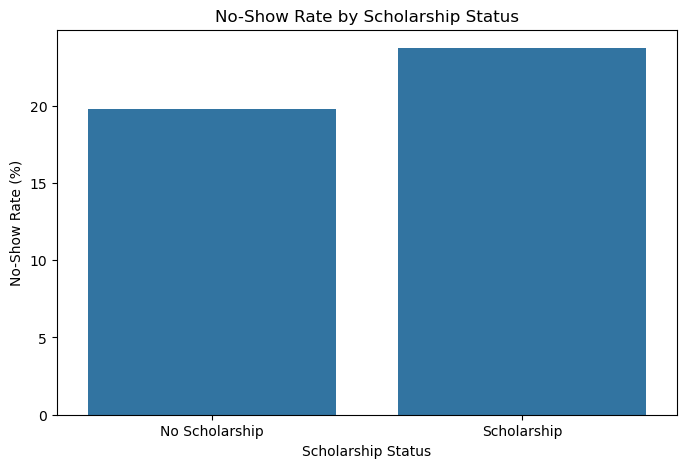

In [162]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=scholarship_no_show.index,
    y=scholarship_no_show.values
)

plt.title("No-Show Rate by Scholarship Status")
plt.xlabel("Scholarship Status")
plt.ylabel("No-Show Rate (%)")

plt.show()

## 4.8 Medical Conditions and No-Show Analysis

The relationship between selected patient medical characteristics
and appointment no-shows is examined to identify whether
attendance patterns differ according to patient health conditions.

In [163]:
medical_columns = [
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap"
]

medical_no_show = (
    df_clean
    .groupby(medical_columns)["no_show_target"]
    .mean()
    * 100
)

In [164]:
hypertension_rate = (
    df_clean
    .groupby("hypertension")["no_show_target"]
    .mean()
    * 100
)

hypertension_rate

hypertension
0    20.899459
1    17.301959
Name: no_show_target, dtype: float64

In [165]:
diabetes_rate = (
    df_clean
    .groupby("diabetes")["no_show_target"]
    .mean()
    * 100
)

diabetes_rate

diabetes
0    20.359141
1    18.003273
Name: no_show_target, dtype: float64

In [166]:
alcoholism_rate = (
    df_clean
    .groupby("alcoholism")["no_show_target"]
    .mean()
    * 100
)

alcoholism_rate

alcoholism
0    20.191114
1    20.148810
Name: no_show_target, dtype: float64

In [167]:
handicap_rate = (
    df_clean
    .groupby("handicap")["no_show_target"]
    .mean()
    * 100
)

handicap_rate

handicap
0    20.233280
1    17.843137
2    20.218579
3    23.076923
4    33.333333
Name: no_show_target, dtype: float64

## 4.9 Neighbourhood-wise No-Show Analysis

Neighbourhood-level no-show rates are analyzed to identify areas
with relatively high appointment non-attendance while avoiding
misleading results from neighbourhoods with very few appointments.

In [168]:
neighbourhood_summary = (
    df_clean
    .groupby("neighbourhood")
    .agg(
        appointments=("appointment_id", "count"),
        no_show_rate=("no_show_target", "mean")
    )
)

neighbourhood_summary["no_show_rate"] *= 100

In [169]:
neighbourhood_filtered = (
    neighbourhood_summary[
        neighbourhood_summary["appointments"] >= 100
    ]
    .sort_values(
        "no_show_rate",
        ascending=False
    )
)

In [171]:
neighbourhood_filtered.head(10)

,appointments,no_show_rate
neighbourhood,,
SANTOS DUMONT,1276,28.918495
SANTA CECÍLIA,448,27.455357
SANTA CLARA,506,26.482213
ITARARÉ,3514,26.266363
JESUS DE NAZARETH,2853,24.395373
HORTO,175,24.000000
ILHA DO PRÍNCIPE,2266,23.477493
CARATOÍRA,2565,23.040936
ANDORINHAS,2262,23.032714


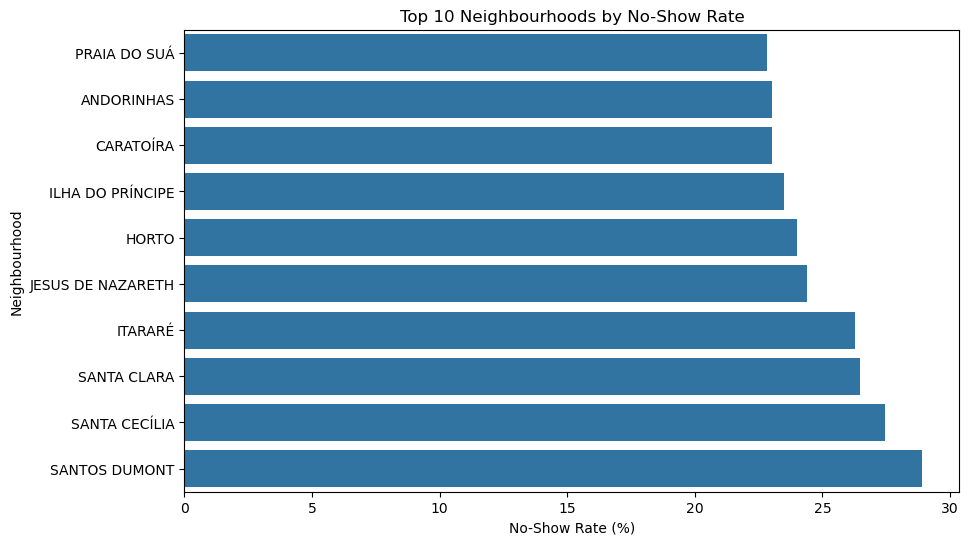

In [172]:
top_neighbourhoods = (
    neighbourhood_filtered
    .head(10)
    .sort_values("no_show_rate")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_neighbourhoods,
    x="no_show_rate",
    y=top_neighbourhoods.index
)

plt.title("Top 10 Neighbourhoods by No-Show Rate")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Neighbourhood")

plt.show()

## 4.10 Correlation Analysis

Correlation analysis is performed to examine relationships between
numerical variables and the appointment no-show target.

In [173]:
correlation_columns = [
    "age",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received",
    "waiting_days",
    "no_show_target"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

In [174]:
correlation_matrix

,age,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,waiting_days,no_show_target
age,1.000000,-0.092469,0.504599,0.292398,0.095811,0.078101,0.012629,0.034813,-0.060320
scholarship,-0.092469,1.000000,-0.019738,-0.024899,0.035019,-0.008555,0.001182,-0.030435,0.029166
hypertension,0.504599,-0.019738,1.000000,0.433082,0.087967,0.080162,-0.006285,-0.017236,-0.035662
diabetes,0.292398,-0.024899,0.433082,1.000000,0.018471,0.057578,-0.014561,-0.027200,-0.015158
alcoholism,0.095811,0.035019,0.087967,0.018471,1.000000,0.004668,-0.026154,-0.038527,-0.000181
handicap,0.078101,-0.008555,0.080162,0.057578,0.004668,1.000000,-0.024097,-0.019774,-0.006290
sms_received,0.012629,0.001182,-0.006285,-0.014561,-0.026154,-0.024097,1.000000,0.398128,0.126502
waiting_days,0.034813,-0.030435,-0.017236,-0.027200,-0.038527,-0.019774,0.398128,1.000000,0.186320
no_show_target,-0.060320,0.029166,-0.035662,-0.015158,-0.000181,-0.006290,0.126502,0.186320,1.000000


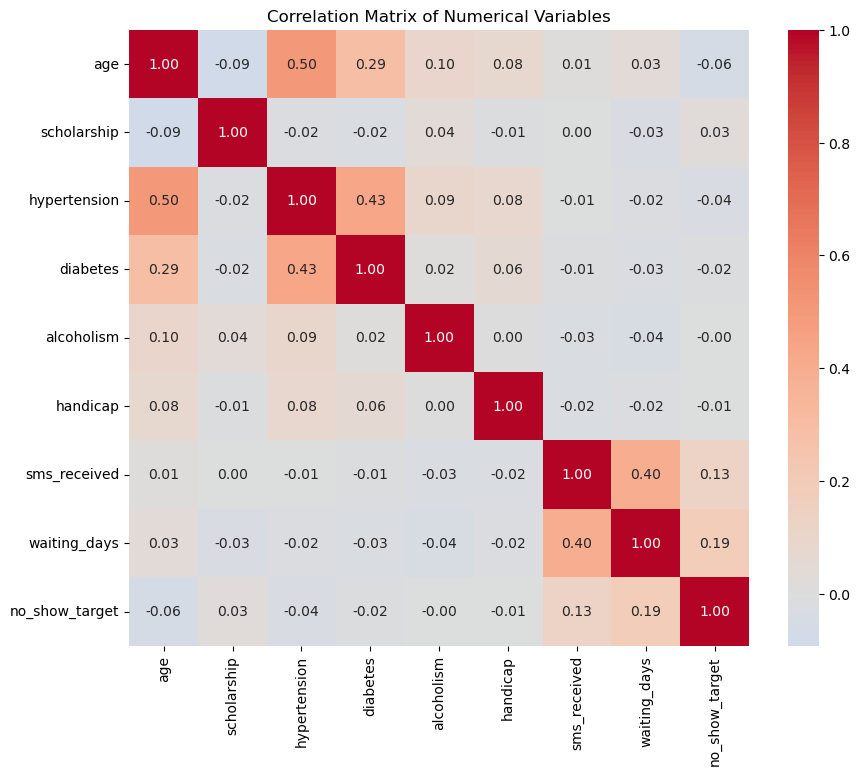

In [175]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [176]:
no_show_correlations = (
    correlation_matrix["no_show_target"]
    .sort_values(
        ascending=False
    )
)

no_show_correlations

no_show_target    1.000000
waiting_days      0.186320
sms_received      0.126502
scholarship       0.029166
alcoholism       -0.000181
handicap         -0.006290
diabetes         -0.015158
hypertension     -0.035662
age              -0.060320
Name: no_show_target, dtype: float64

In [177]:
eda_summary = pd.DataFrame({
    "Analysis": [
        "Gender",
        "Age Group",
        "SMS Reminder",
        "Waiting Time",
        "Weekday",
        "Scholarship"
    ],
    "Result": [
        gender_no_show.to_dict(),
        age_no_show.to_dict(),
        sms_no_show.to_dict(),
        waiting_no_show.to_dict(),
        weekday_no_show.to_dict(),
        scholarship_no_show.to_dict()
    ]
})

eda_summary

,Analysis,Result
0,Gender,"{'F': 20.311542958962082, 'M': 19.9638102623756}"
1,Age Group,"{'0-12': 20.47064416448776, '13-18': 26.053639..."
2,SMS Reminder,"{'No SMS': 16.697983715134797, 'SMS Received':..."
3,Waiting Time,"{'Same day': 4.647061874384108, '1-3 days': 22..."
4,Weekday,"{'Monday': 20.64456478668604, 'Tuesday': 20.08..."
5,Scholarship,"{'No Scholarship': 19.803331326510136, 'Schola..."


## 4.11 EDA Summary

The exploratory analysis examined appointment attendance patterns
across demographic, appointment and patient-related variables.

Key areas investigated included gender, age groups, SMS reminders,
waiting time, appointment weekdays, scholarship status, medical
conditions and neighbourhood.

The findings from these analyses will be used to guide feature
selection and machine learning model development.

# 5. Feature Engineering and ML Data Preparation

In this section, the cleaned dataset is transformed into a suitable
format for machine learning.

The process includes selecting relevant features, encoding
categorical variables, defining the target variable, splitting the
data into training and testing sets, and preparing numerical
features for model development.

In [178]:
print(df_clean.columns.tolist())

['patient_id', 'appointment_id', 'gender', 'scheduled_date', 'appointment_date', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show', 'no_show_target', 'waiting_days', 'appointment_weekday', 'appointment_month', 'age_group', 'waiting_group']


In [179]:
features = [
    "age",
    "gender",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received",
    "waiting_days",
    "appointment_weekday",
    "appointment_month"]

In [180]:
X = df_clean[features].copy()

In [181]:
y = df_clean["no_show_target"].copy()

In [182]:
X.head()

,age,gender,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,waiting_days,appointment_weekday,appointment_month
0,62,F,0,1,0,0,0,0,0,Friday,4
1,56,M,0,0,0,0,0,0,0,Friday,4
2,62,F,0,0,0,0,0,0,0,Friday,4
3,8,F,0,0,0,0,0,0,0,Friday,4
4,56,F,0,1,1,0,0,0,0,Friday,4


In [183]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: no_show_target, dtype: int64

In [184]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110521, 11)
y shape: (110521,)


In [185]:
print("Missing values in X:")
print(X.isnull().sum())

Missing values in X:
age                    0
gender                 0
scholarship            0
hypertension           0
diabetes               0
alcoholism             0
handicap               0
sms_received           0
waiting_days           0
appointment_weekday    0
appointment_month      0
dtype: int64


In [186]:
print("Missing values in y:", y.isnull().sum())

Missing values in y: 0


In [187]:
categorical_features = [
    "gender",
    "appointment_weekday"
]

In [188]:
numerical_features = [
    "age",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received",
    "waiting_days",
    "appointment_month"
]

In [189]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [190]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"),
            categorical_features )],
    remainder="passthrough")

In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y)

In [192]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (88416, 11)
X_test : (22105, 11)
y_train: (88416,)
y_test : (22105,)


In [193]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
no_show_target
0    70565
1    17851
Name: count, dtype: int64

Testing target distribution:
no_show_target
0    17642
1     4463
Name: count, dtype: int64


In [194]:
X_train_processed = preprocessor.fit_transform(X_train)

In [195]:
X_test_processed = preprocessor.transform(X_test)

In [196]:
print(
    "Processed training shape:",
    X_train_processed.shape)

print(
    "Processed testing shape:",
    X_test_processed.shape)

Processed training shape: (88416, 15)
Processed testing shape: (22105, 15)


In [197]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [199]:
ml_preparation_summary = {
    "Original_rows": len(df),
    "Cleaned_rows": len(df_clean),
    "Features_used": len(features),
    "Training_rows": len(X_train),
    "Testing_rows": len(X_test),
    "Target": "no_show_target",
    "Test_size": 0.20,
    "Random_state": 42
}

ml_preparation_summary

{'Original_rows': 110527,
 'Cleaned_rows': 110521,
 'Features_used': 11,
 'Training_rows': 88416,
 'Testing_rows': 22105,
 'Target': 'no_show_target',
 'Test_size': 0.2,
 'Random_state': 42}

In [200]:
print("===== ML DATA PREPARATION CHECK =====")

print("Cleaned dataset:", df_clean.shape)

print("X:", X.shape)
print("y:", y.shape)

print("\nTraining:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nProcessed:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

===== ML DATA PREPARATION CHECK =====
Cleaned dataset: (110521, 20)
X: (110521, 11)
y: (110521,)

Training:
X_train: (88416, 11)
y_train: (88416,)

Testing:
X_test: (22105, 11)
y_test: (22105,)

Processed:
X_train_processed: (88416, 15)
X_test_processed: (22105, 15)


# 6. Machine Learning Model Development

Classification models are developed to predict whether a patient
will attend or miss a scheduled healthcare appointment.

The target variable is:

0 = Attended
1 = No-show

The models developed are:
1. Logistic Regression
2. Decision Tree
3. Random Forest

In [201]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 6.1 Logistic Regression

Logistic Regression is used as the baseline classification model
for predicting whether an appointment will result in a no-show.

In [202]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [203]:
logistic_model = Pipeline([
    ("scaler",StandardScaler()),
    ("classifier",LogisticRegression(max_iter=1000,random_state=42))])

In [204]:
logistic_model.fit(
    X_train_processed,
    y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [205]:
y_pred_logistic = logistic_model.predict(X_test_processed)

In [206]:
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [207]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic)

In [208]:
print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.7952
Precision: 0.3367
Recall   : 0.0148
F1 Score : 0.0283
ROC-AUC  : 0.6578


In [209]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "Attended",
            "No-show"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Attended       0.80      0.99      0.89     17642
     No-show       0.34      0.01      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.57      0.50      0.46     22105
weighted avg       0.71      0.80      0.71     22105



### Confusion Matrix — Logistic Regression

In [210]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic)

print(cm_logistic)

[[17512   130]
 [ 4397    66]]


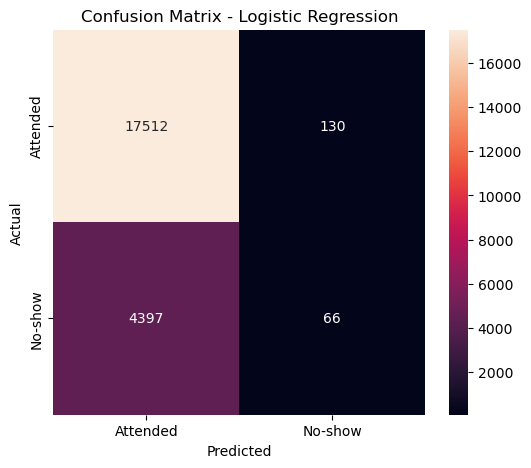

In [211]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["Attended", "No-show"],
    yticklabels=["Attended", "No-show"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 6.2 Decision Tree Classifier

A Decision Tree is developed to capture non-linear relationships
between patient and appointment characteristics and the likelihood
of a no-show.

In [212]:
decision_tree = DecisionTreeClassifier(
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

In [213]:
decision_tree.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

In [214]:
y_pred_tree = decision_tree.predict(
    X_test_processed
)

In [215]:
y_prob_tree = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

In [216]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

In [217]:
print("Decision Tree Results")
print("--------------------")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")

Decision Tree Results
--------------------
Accuracy : 0.5874
Precision: 0.3026
Recall   : 0.7999
F1 Score : 0.4391
ROC-AUC  : 0.7176


In [218]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "Attended",
            "No-show"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Attended       0.91      0.53      0.67     17642
     No-show       0.30      0.80      0.44      4463

    accuracy                           0.59     22105
   macro avg       0.61      0.67      0.56     22105
weighted avg       0.79      0.59      0.63     22105



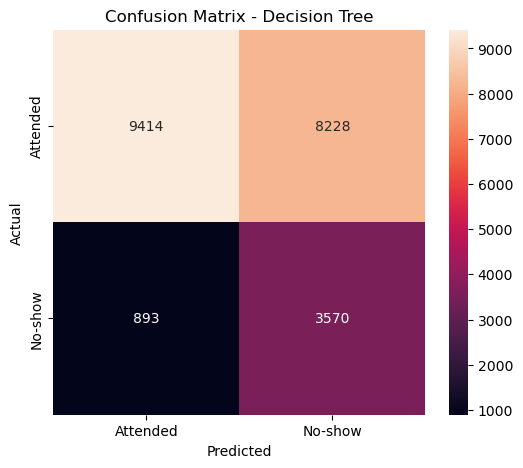

In [219]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    xticklabels=["Attended", "No-show"],
    yticklabels=["Attended", "No-show"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 6.3 Random Forest Classifier

Random Forest is developed as an ensemble classification model
to improve predictive performance by combining multiple decision
trees

In [220]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1)

In [221]:
random_forest.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [222]:
y_pred_rf = random_forest.predict(
    X_test_processed
)

In [223]:
y_prob_rf = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [224]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

In [225]:
print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.5803
Precision: 0.3028
Recall   : 0.8281
F1 Score : 0.4434
ROC-AUC  : 0.7230


In [226]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Attended",
            "No-show"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Attended       0.92      0.52      0.66     17642
     No-show       0.30      0.83      0.44      4463

    accuracy                           0.58     22105
   macro avg       0.61      0.67      0.55     22105
weighted avg       0.80      0.58      0.62     22105



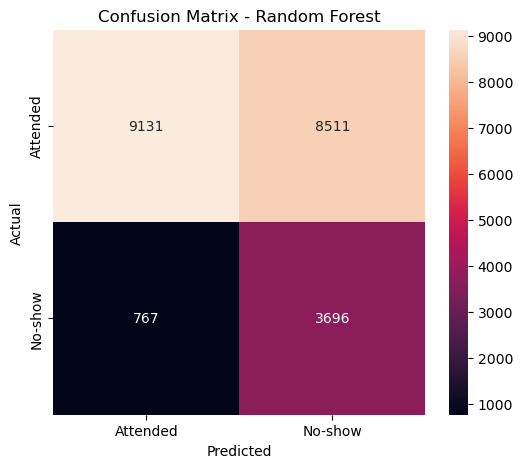

In [227]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Attended", "No-show"],
    yticklabels=["Attended", "No-show"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [228]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1],
    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7952,0.3367,0.0148,0.0283,0.6578
1,Decision Tree,0.5874,0.3026,0.7999,0.4391,0.7176
2,Random Forest,0.5803,0.3028,0.8281,0.4434,0.7230


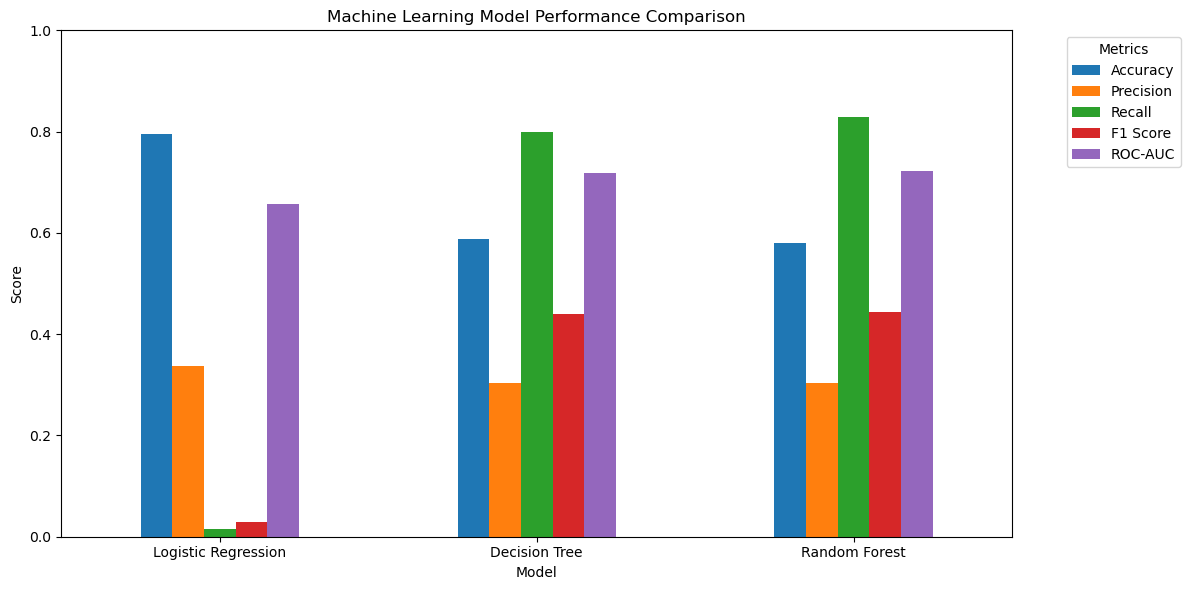

In [229]:
model_results_plot = model_results.set_index("Model")

model_results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Phase 7 Model Comparison — Conclusion

Three classification models were developed: Logistic Regression,
Decision Tree and Random Forest.

Random Forest achieved the highest recall (82.81%), F1-score (44.34%)
and ROC-AUC (72.30%) among the three models. Although its accuracy
(58.03%) was lower than Logistic Regression, it identified a much
larger proportion of actual appointment no-shows.

Since the primary objective of this project is to identify
appointments at high risk of no-show, Random Forest was selected
as the preliminary best-performing model.

# 7. Model Evaluation and Interpretation

The trained classification models are evaluated using confusion
matrices, classification metrics, ROC-AUC, precision-recall analysis,
and feature importance.

The evaluation focuses particularly on identifying patients who are
at high risk of missing their appointments.

In [231]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Attended",
            "No-show"],
        zero_division=0))

              precision    recall  f1-score   support

    Attended       0.92      0.52      0.66     17642
     No-show       0.30      0.83      0.44      4463

    accuracy                           0.58     22105
   macro avg       0.61      0.67      0.55     22105
weighted avg       0.80      0.58      0.62     22105



In [232]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[9131 8511]
 [ 767 3696]]


In [233]:
tn, fp, fn, tp = cm_rf.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 9131
False Positives: 8511
False Negatives: 767
True Positives  : 3696


In [234]:
print("Accuracy :", (tp + tn) / (tp + tn + fp + fn))
print("Precision:", tp / (tp + fp))
print("Recall   :", tp / (tp + fn))
print("F1 Score :", 2 * (tp / (tp + fp)) * (tp / (tp + fn)) /
      ((tp / (tp + fp)) + (tp / (tp + fn))))

Accuracy : 0.5802759556661389
Precision: 0.30277709510936346
Recall   : 0.8281425050414519
F1 Score : 0.44343131373725253


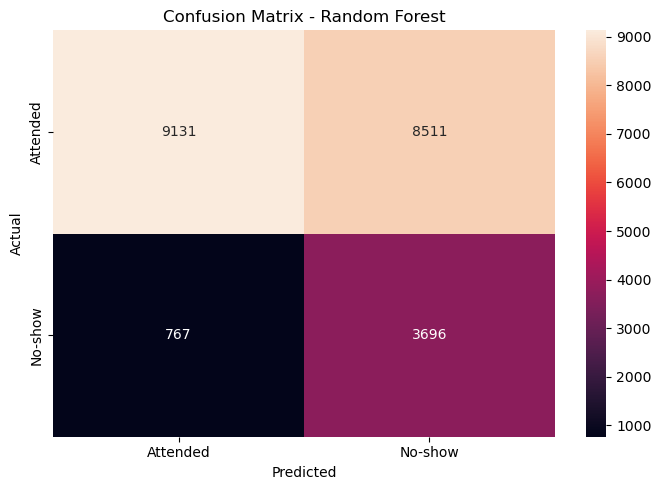

In [235]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Attended", "No-show"],
    yticklabels=["Attended", "No-show"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## 7.1 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to
evaluate the ability of the Random Forest model to distinguish
between attended and no-show appointments across different
classification thresholds.

In [236]:
from sklearn.metrics import roc_curve

In [237]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_rf)

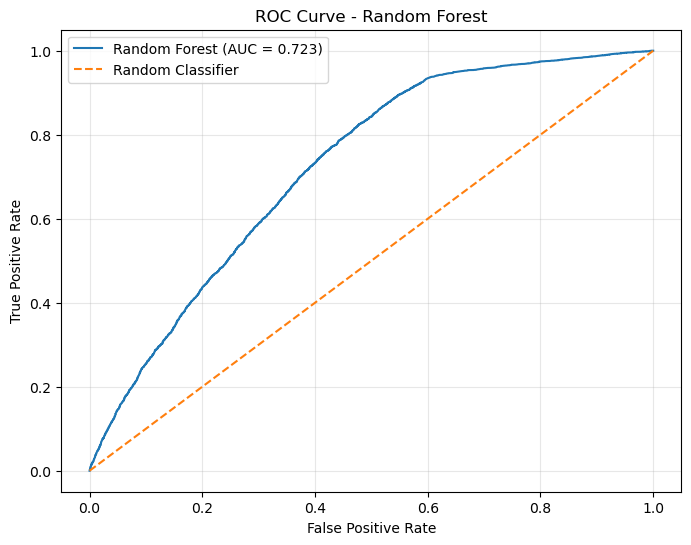

In [238]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7.2 Precision-Recall Curve

The Precision-Recall curve is examined because appointment no-show
is the minority class. It shows the trade-off between correctly
identifying no-shows and avoiding false alarms.

In [239]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [240]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_prob_rf))

average_precision = average_precision_score(
    y_test,
    y_prob_rf)

print(
    "Average Precision:",
    round(average_precision, 4))

Average Precision: 0.354


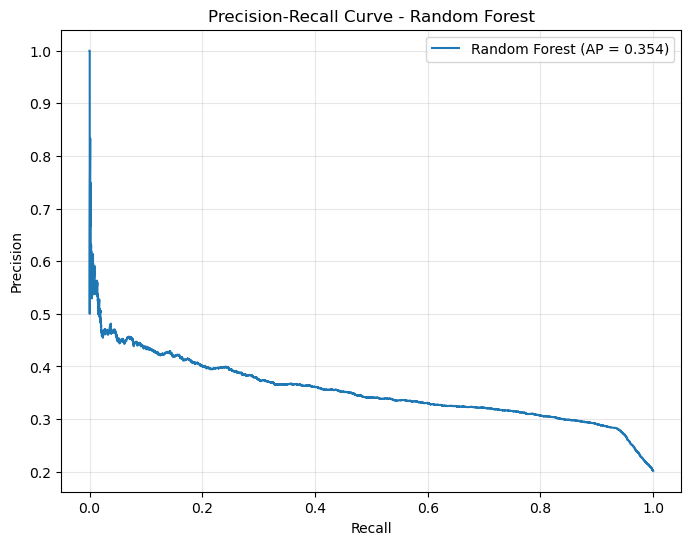

In [241]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Random Forest (AP = {average_precision:.3f})"
)

plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7.3 Random Forest Feature Importance

Feature importance is analyzed to identify which patient and
appointment characteristics contribute most to the Random Forest's
predictions.

In [242]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['categorical__gender_M' 'categorical__appointment_weekday_Monday'
 'categorical__appointment_weekday_Saturday'
 'categorical__appointment_weekday_Thursday'
 'categorical__appointment_weekday_Tuesday'
 'categorical__appointment_weekday_Wednesday' 'remainder__age'
 'remainder__scholarship' 'remainder__hypertension' 'remainder__diabetes'
 'remainder__alcoholism' 'remainder__handicap' 'remainder__sms_received'
 'remainder__waiting_days' 'remainder__appointment_month']


In [243]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_
})

In [244]:
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [245]:
feature_importance.head(15)

,Feature,Importance
13,remainder__waiting_days,0.725057
6,remainder__age,0.119974
12,remainder__sms_received,0.067633
14,remainder__appointment_month,0.013597
0,categorical__gender_M,0.011599
8,remainder__hypertension,0.010612
7,remainder__scholarship,0.009628
11,remainder__handicap,0.008596
10,remainder__alcoholism,0.006665
1,categorical__appointment_weekday_Monday,0.005974


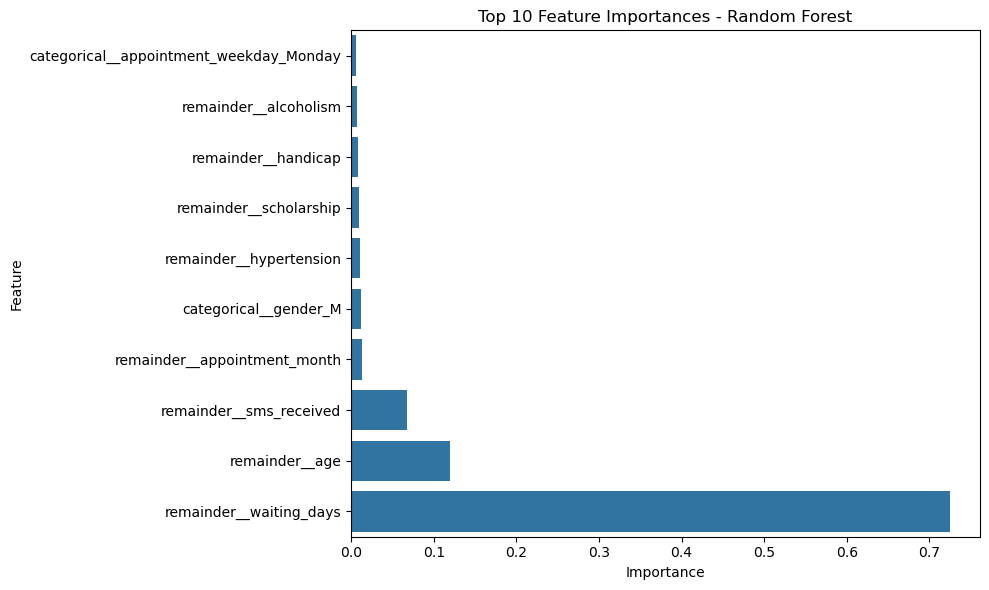

In [246]:
top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [247]:
final_model_comparison = model_results.copy()

final_model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.795205,0.336735,0.014788,0.028332,0.657774
1,Decision Tree,0.587378,0.302594,0.799910,0.439087,0.717605
2,Random Forest,0.580276,0.302777,0.828143,0.443431,0.722951


In [248]:
print(final_model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7952     0.3367  0.0148    0.0283   0.6578
1        Decision Tree    0.5874     0.3026  0.7999    0.4391   0.7176
2        Random Forest    0.5803     0.3028  0.8281    0.4434   0.7230


## 7.4 Final Model Selection

Random Forest was selected as the final model because it achieved
the highest recall, F1-score and ROC-AUC among the evaluated models.

The model achieved a recall of approximately 82.81%, meaning that it
identified a large proportion of the actual no-show appointments.

Although Logistic Regression achieved higher overall accuracy,
its no-show recall was only approximately 1.48%, making it less
suitable for the primary objective of identifying high-risk
no-show appointments.

Therefore, Random Forest is selected as the final predictive model.

In [249]:
import joblib

In [250]:
model_path = "random_forest_no_show_model.pkl"

joblib.dump(
    random_forest,
    model_path
)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
random_forest_no_show_model.pkl


In [251]:
preprocessor_path = "no_show_preprocessor.pkl"

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("Preprocessor saved successfully!")
print(preprocessor_path)

Preprocessor saved successfully!
no_show_preprocessor.pkl


In [252]:
feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [253]:
model_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


### Phase 8 Findings

The Random Forest model achieved a no-show recall of approximately
82.81% and an F1-score of approximately 44.34%.

The confusion matrix showed 3,696 correctly identified no-show
appointments and 767 false negatives. However, the model also
generated 8,511 false positives, resulting in a relatively low
no-show precision of approximately 30%.

Feature importance analysis showed that waiting days was the most
important predictive feature, with an importance of approximately
72.51%. Age and SMS reminder status were the second and third most
important features.

These results indicate that waiting time, age and SMS reminder
status are important predictive factors for appointment no-shows.

Feature importance represents predictive contribution and should
not be interpreted as causal evidence.

In [255]:
import joblib

joblib.dump(
    random_forest,
    "random_forest_no_show_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [257]:

joblib.dump(
    random_forest,
    "random_forest_no_show_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


# 8. Prediction and Risk Segmentation

The final Random Forest model is used to generate no-show
probabilities for appointments.

Appointments are then categorized into Low, Medium, and High
risk groups to support targeted intervention and appointment
management.

In [258]:
X_all_processed = preprocessor.transform(X)

In [259]:
all_no_show_probabilities = random_forest.predict_proba(
    X_all_processed
)[:, 1]

In [260]:
print("Number of predictions:", len(all_no_show_probabilities))

Number of predictions: 110521


In [261]:
print("Minimum probability:",
      all_no_show_probabilities.min())

print("Maximum probability:",
      all_no_show_probabilities.max())

print("Average probability:",
      all_no_show_probabilities.mean())

Minimum probability: 0.02466469796439744
Maximum probability: 0.8295571007792245
Average probability: 0.4434246796098823


In [262]:
final_predictions = df_clean.copy()

In [263]:
final_predictions["no_show_probability"] = (
    all_no_show_probabilities
)

In [264]:
final_predictions[
    [
        "appointment_id",
        "no_show_target",
        "no_show_probability"
    ]
].head(10)

,appointment_id,no_show_target,no_show_probability
0,5642903,0,0.093210
1,5642503,0,0.125401
2,5642549,0,0.100746
3,5642828,0,0.208642
4,5642494,0,0.106285
5,5626772,0,0.475204
6,5630279,1,0.645093
7,5630575,1,0.611442
8,5638447,0,0.165838
9,5629123,0,0.644862


In [265]:
final_predictions["predicted_no_show"] = (
    final_predictions["no_show_probability"] >= 0.50
).astype(int)

In [266]:
print(
    final_predictions["predicted_no_show"]
    .value_counts()
)

predicted_no_show
1    60633
0    49888
Name: count, dtype: int64


In [267]:
def assign_risk(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

In [268]:
final_predictions["risk_level"] = (
    final_predictions["no_show_probability"]
    .apply(assign_risk)
)

In [269]:
risk_distribution = (
    final_predictions["risk_level"]
    .value_counts()
)

print(risk_distribution)

risk_level
Medium    39519
Low       36266
High      34736
Name: count, dtype: int64


In [270]:
risk_percentage = (
    final_predictions["risk_level"]
    .value_counts(normalize=True) * 100
)

print(risk_percentage.round(2))

risk_level
Medium    35.76
Low       32.81
High      31.43
Name: proportion, dtype: float64


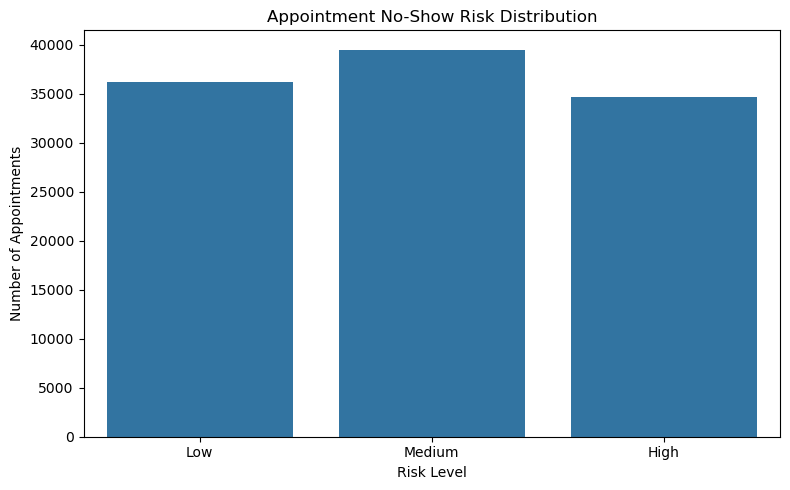

In [271]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=final_predictions,
    x="risk_level",
    order=["Low", "Medium", "High"]
)

plt.title("Appointment No-Show Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.show()

In [272]:
risk_performance = (
    final_predictions
    .groupby("risk_level")["no_show_target"]
    .agg(
        total_appointments="count",
        actual_no_shows="sum",
        no_show_rate="mean"
    )
    .reindex(["Low", "Medium", "High"])
)

risk_performance["no_show_rate"] = (
    risk_performance["no_show_rate"] * 100
)

risk_performance

,total_appointments,actual_no_shows,no_show_rate
risk_level,,,
Low,36266,1287,3.548778
Medium,39519,8213,20.782408
High,34736,12814,36.889682


In [273]:
print(final_predictions.columns.tolist())

['patient_id', 'appointment_id', 'gender', 'scheduled_date', 'appointment_date', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show', 'no_show_target', 'waiting_days', 'appointment_weekday', 'appointment_month', 'age_group', 'waiting_group', 'no_show_probability', 'predicted_no_show', 'risk_level']


In [274]:
final_output = final_predictions[
    [
        "appointment_id",
        "patient_id",
        "appointment_date",
        "scheduled_date",
        "waiting_days",
        "age",
        "gender",
        "sms_received",
        "scholarship",
        "hypertension",
        "diabetes",
        "no_show_target",
        "no_show_probability",
        "predicted_no_show",
        "risk_level"
    ]
].copy()

In [275]:
final_output = final_output.rename(
    columns={
        "no_show_target": "actual_no_show"
    }
)

In [276]:
final_output["no_show_probability"] = (
    final_output["no_show_probability"]
    .round(4)
)

In [277]:
final_output.head(10)

,appointment_id,patient_id,appointment_date,scheduled_date,waiting_days,age,gender,sms_received,scholarship,hypertension,diabetes,actual_no_show,no_show_probability,predicted_no_show,risk_level
0,5642903,2.987250e+13,2016-04-29 00:00:00+00:00,2016-04-29 18:38:08+00:00,0,62,F,0,0,1,0,0,0.0932,0,Low
1,5642503,5.589980e+14,2016-04-29 00:00:00+00:00,2016-04-29 16:08:27+00:00,0,56,M,0,0,0,0,0,0.1254,0,Low
2,5642549,4.262960e+12,2016-04-29 00:00:00+00:00,2016-04-29 16:19:04+00:00,0,62,F,0,0,0,0,0,0.1007,0,Low
3,5642828,8.679510e+11,2016-04-29 00:00:00+00:00,2016-04-29 17:29:31+00:00,0,8,F,0,0,0,0,0,0.2086,0,Low
4,5642494,8.841190e+12,2016-04-29 00:00:00+00:00,2016-04-29 16:07:23+00:00,0,56,F,0,0,1,1,0,0.1063,0,Low
5,5626772,9.598510e+13,2016-04-29 00:00:00+00:00,2016-04-27 08:36:51+00:00,2,76,F,0,0,1,0,0,0.4752,0,Medium
6,5630279,7.336880e+14,2016-04-29 00:00:00+00:00,2016-04-27 15:05:12+00:00,2,23,F,0,0,0,0,1,0.6451,1,High
7,5630575,3.449830e+12,2016-04-29 00:00:00+00:00,2016-04-27 15:39:58+00:00,2,39,F,0,0,0,0,1,0.6114,1,High
8,5638447,5.639470e+13,2016-04-29 00:00:00+00:00,2016-04-29 08:02:16+00:00,0,21,F,0,0,0,0,0,0.1658,0,Low
9,5629123,7.812460e+13,2016-04-29 00:00:00+00:00,2016-04-27 12:48:25+00:00,2,19,F,0,0,0,0,0,0.6449,1,High


In [278]:
print("Final prediction shape:", final_output.shape)

Final prediction shape: (110521, 15)


In [279]:
print(
    "Missing values:",
    final_output.isnull().sum().sum()
)

Missing values: 0


In [280]:
print(
    "Duplicate appointment IDs:",
    final_output["appointment_id"].duplicated().sum()
)

Duplicate appointment IDs: 0


In [281]:
import os

project_path = r"C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show"
data_path = os.path.join(project_path, "data")

os.makedirs(data_path, exist_ok=True)

final_prediction_path = os.path.join(
    data_path,
    "final_no_show_predictions.csv"
)

final_output.to_csv(
    final_prediction_path,
    index=False
)

print("Final prediction CSV saved successfully!")
print(final_prediction_path)

Final prediction CSV saved successfully!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\final_no_show_predictions.csv


In [282]:
print(
    os.path.exists(final_prediction_path)
)

True


In [283]:
print(
    os.path.getsize(final_prediction_path),
    "bytes"
)

12050457 bytes


In [284]:
high_risk_appointments = final_output[
    final_output["risk_level"] == "High"
].copy()

In [285]:
print(
    "High-risk appointments:",
    len(high_risk_appointments)
)

High-risk appointments: 34736


In [286]:
high_risk_path = os.path.join(
    data_path,
    "high_risk_no_show_appointments.csv"
)

high_risk_appointments.to_csv(
    high_risk_path,
    index=False
)

print("High-risk CSV saved successfully!")
print(high_risk_path)

High-risk CSV saved successfully!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\high_risk_no_show_appointments.csv


In [287]:
prediction_summary = {
    "Total appointments": len(final_output),
    "Predicted no-shows": (
        final_output["predicted_no_show"].sum()
    ),
    "Low-risk appointments": (
        (final_output["risk_level"] == "Low").sum()
    ),
    "Medium-risk appointments": (
        (final_output["risk_level"] == "Medium").sum()
    ),
    "High-risk appointments": (
        (final_output["risk_level"] == "High").sum()
    )
}

prediction_summary

{'Total appointments': 110521,
 'Predicted no-shows': np.int64(60633),
 'Low-risk appointments': np.int64(36266),
 'Medium-risk appointments': np.int64(39519),
 'High-risk appointments': np.int64(34736)}

### Phase 9 Conclusion

The Random Forest model was used to generate no-show probabilities
for all appointments in the cleaned dataset.

Based on predicted probability, appointments were categorized into
Low, Medium, and High risk groups. A separate high-risk appointment
dataset was also generated for targeted intervention.

The final prediction dataset contains appointment information,
predicted no-show probability, predicted outcome, and risk category.

In [288]:
print("Minimum probability:", all_no_show_probabilities.min())
print("Maximum probability:", all_no_show_probabilities.max())
print("Average probability:", all_no_show_probabilities.mean())

Minimum probability: 0.02466469796439744
Maximum probability: 0.8295571007792245
Average probability: 0.4434246796098823


In [289]:
print(risk_distribution)

risk_level
Medium    39519
Low       36266
High      34736
Name: count, dtype: int64


In [290]:
risk_performance

,total_appointments,actual_no_shows,no_show_rate
risk_level,,,
Low,36266,1287,3.548778
Medium,39519,8213,20.782408
High,34736,12814,36.889682


In [291]:
print("Final prediction shape:", final_output.shape)

Final prediction shape: (110521, 15)


In [292]:
print("Missing values:", final_output.isnull().sum().sum())

Missing values: 0


# 10. Threshold Optimization and Final Model Selection

The Random Forest model currently uses a classification threshold of
0.50 to classify appointments as attended or no-show.

Threshold optimization is performed to identify a suitable balance
between precision and recall for detecting appointment no-shows.

The selected threshold will be used for the final prediction system.

In [293]:
thresholds_to_test = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

print(thresholds_to_test)

[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


In [294]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [295]:
threshold_results = []

In [298]:
for threshold in thresholds_to_test:

    y_pred_threshold = (
        y_prob_rf >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1 })

In [299]:
threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.2,0.440579,0.259539,0.955635,0.408212
1,0.3,0.501968,0.280630,0.938158,0.432028
2,0.4,0.517304,0.284972,0.921577,0.435330
3,0.5,0.580276,0.302777,0.828143,0.443431
4,0.6,0.696177,0.338818,0.530585,0.413552
5,0.7,0.796924,0.465969,0.039883,0.073478
6,0.8,0.798100,0.000000,0.000000,0.000000


In [300]:
threshold_results_df.round(4)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.2,0.4406,0.2595,0.9556,0.4082
1,0.3,0.5020,0.2806,0.9382,0.4320
2,0.4,0.5173,0.2850,0.9216,0.4353
3,0.5,0.5803,0.3028,0.8281,0.4434
4,0.6,0.6962,0.3388,0.5306,0.4136
5,0.7,0.7969,0.4660,0.0399,0.0735
6,0.8,0.7981,0.0000,0.0000,0.0000


In [301]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()]

print(best_f1_row)

Threshold    0.500000
Accuracy     0.580276
Precision    0.302777
Recall       0.828143
F1 Score     0.443431
Name: 3, dtype: float64


In [302]:
best_threshold = best_f1_row["Threshold"]

print(
    "Best threshold based on F1:",
    best_threshold
)

Best threshold based on F1: 0.5


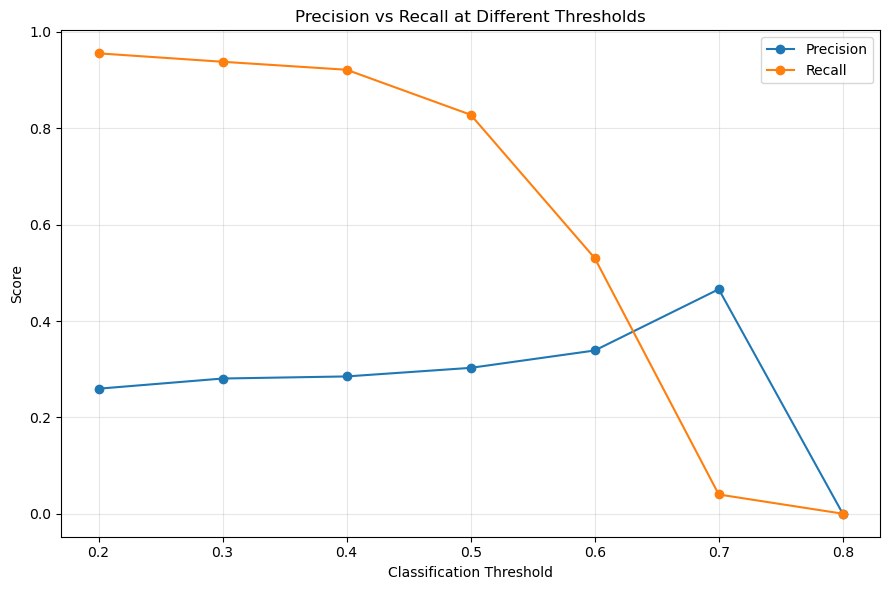

In [303]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

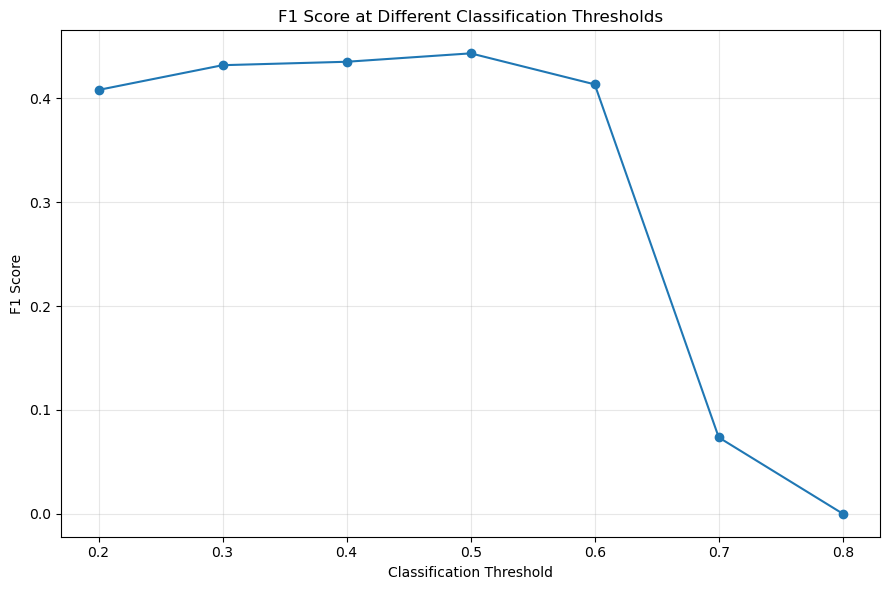

In [304]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1 Score"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score at Different Classification Thresholds")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [305]:
print("===================================")
print("FINAL THRESHOLD ANALYSIS")
print("===================================")

print(
    "Best Threshold:",
    round(float(best_threshold), 2)
)

print(
    "Accuracy:",
    round(best_f1_row["Accuracy"], 4)
)

print(
    "Precision:",
    round(best_f1_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_f1_row["Recall"], 4)
)

print(
    "F1 Score:",
    round(best_f1_row["F1 Score"], 4)
)

FINAL THRESHOLD ANALYSIS
Best Threshold: 0.5
Accuracy: 0.5803
Precision: 0.3028
Recall: 0.8281
F1 Score: 0.4434


In [306]:
final_threshold_predictions = (
    y_prob_rf >= best_threshold
).astype(int)

In [307]:
final_cm = confusion_matrix(
    y_test,
    final_threshold_predictions
)

print(final_cm)

[[9131 8511]
 [ 767 3696]]


In [308]:
final_tn, final_fp, final_fn, final_tp = (
    final_cm.ravel()
)

print("True Negatives :", final_tn)
print("False Positives:", final_fp)
print("False Negatives:", final_fn)
print("True Positives  :", final_tp)

True Negatives : 9131
False Positives: 8511
False Negatives: 767
True Positives  : 3696


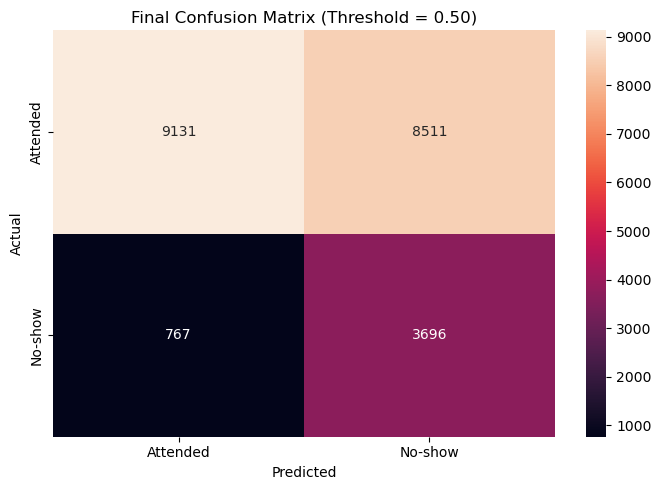

In [309]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Attended", "No-show"],
    yticklabels=["Attended", "No-show"]
)

plt.title(
    f"Final Confusion Matrix "
    f"(Threshold = {best_threshold:.2f})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [310]:
print(
    classification_report(
        y_test,
        final_threshold_predictions,
        target_names=[
            "Attended",
            "No-show"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Attended       0.92      0.52      0.66     17642
     No-show       0.30      0.83      0.44      4463

    accuracy                           0.58     22105
   macro avg       0.61      0.67      0.55     22105
weighted avg       0.80      0.58      0.62     22105



In [311]:
default_threshold = 0.50

default_predictions = (
    y_prob_rf >= default_threshold
).astype(int)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Threshold 0.50": [
        accuracy_score(y_test, default_predictions),
        precision_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            default_predictions,
            zero_division=0
        )
    ],

    "Optimized Threshold": [
        accuracy_score(
            y_test,
            final_threshold_predictions
        ),
        precision_score(
            y_test,
            final_threshold_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            final_threshold_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            final_threshold_predictions,
            zero_division=0
        )
    ]
})

comparison.round(4)

,Metric,Threshold 0.50,Optimized Threshold
0,Accuracy,0.5803,0.5803
1,Precision,0.3028,0.3028
2,Recall,0.8281,0.8281
3,F1 Score,0.4434,0.4434


## Threshold Optimization Conclusion

Multiple classification thresholds were evaluated to determine
whether the default probability threshold of 0.50 could be improved.

The threshold of 0.50 produced the highest F1-score among the tested
thresholds and therefore remained the selected classification
threshold.

The final Random Forest model achieved an accuracy of 58.03%,
precision of 30.28%, recall of 82.81%, and F1-score of 44.34%.

The high recall indicates that the model identifies a large
proportion of actual appointment no-shows. However, the relatively
low precision indicates that the model also produces a considerable
number of false-positive predictions.

Since the primary objective of the project is to identify
appointments at high risk of being missed, the Random Forest model
with a 0.50 classification threshold was selected as the final
prediction model.

In [312]:
threshold_results_df.to_csv(
    "threshold_comparison_results.csv",
    index=False
)

print("Threshold comparison saved successfully!")

Threshold comparison saved successfully!


In [313]:
final_model_info = pd.DataFrame({
    "Model": ["Random Forest"],
    "Threshold": [0.50],
    "Accuracy": [0.5803],
    "Precision": [0.3028],
    "Recall": [0.8281],
    "F1 Score": [0.4434],
    "ROC-AUC": [0.7230]
})

final_model_info

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.5,0.5803,0.3028,0.8281,0.4434,0.723


In [314]:
final_model_info.to_csv(
    "final_model_performance.csv",
    index=False
)

print("Final model performance saved successfully!")

Final model performance saved successfully!


In [315]:
final_output.head()

,appointment_id,patient_id,appointment_date,scheduled_date,waiting_days,age,gender,sms_received,scholarship,hypertension,diabetes,actual_no_show,no_show_probability,predicted_no_show,risk_level
0,5642903,2.987250e+13,2016-04-29 00:00:00+00:00,2016-04-29 18:38:08+00:00,0,62,F,0,0,1,0,0,0.0932,0,Low
1,5642503,5.589980e+14,2016-04-29 00:00:00+00:00,2016-04-29 16:08:27+00:00,0,56,M,0,0,0,0,0,0.1254,0,Low
2,5642549,4.262960e+12,2016-04-29 00:00:00+00:00,2016-04-29 16:19:04+00:00,0,62,F,0,0,0,0,0,0.1007,0,Low
3,5642828,8.679510e+11,2016-04-29 00:00:00+00:00,2016-04-29 17:29:31+00:00,0,8,F,0,0,0,0,0,0.2086,0,Low
4,5642494,8.841190e+12,2016-04-29 00:00:00+00:00,2016-04-29 16:07:23+00:00,0,56,F,0,0,1,1,0,0.1063,0,Low


In [316]:
final_output.dtypes

appointment_id                       int64
patient_id                         float64
appointment_date       datetime64[ns, UTC]
scheduled_date         datetime64[ns, UTC]
waiting_days                         int64
age                                  int64
gender                              object
sms_received                         int64
scholarship                          int64
hypertension                         int64
diabetes                             int64
actual_no_show                       int64
no_show_probability                float64
predicted_no_show                    int64
risk_level                          object
dtype: object

In [317]:
final_output["appointment_date"] = pd.to_datetime(
    final_output["appointment_date"]
)

final_output["scheduled_date"] = pd.to_datetime(
    final_output["scheduled_date"]
)

In [318]:
print(
    final_output[
        ["appointment_date", "scheduled_date"]
    ].dtypes
)

appointment_date    datetime64[ns, UTC]
scheduled_date      datetime64[ns, UTC]
dtype: object


In [319]:
final_output["appointment_year"] = (
    final_output["appointment_date"].dt.year
)

final_output["appointment_month"] = (
    final_output["appointment_date"].dt.month
)

final_output["appointment_month_name"] = (
    final_output["appointment_date"].dt.month_name()
)

final_output["appointment_weekday"] = (
    final_output["appointment_date"].dt.day_name()
)

In [320]:
final_output[
    [
        "appointment_date",
        "appointment_year",
        "appointment_month",
        "appointment_month_name",
        "appointment_weekday"
    ]
].head()

,appointment_date,appointment_year,appointment_month,appointment_month_name,appointment_weekday
0,2016-04-29 00:00:00+00:00,2016,4,April,Friday
1,2016-04-29 00:00:00+00:00,2016,4,April,Friday
2,2016-04-29 00:00:00+00:00,2016,4,April,Friday
3,2016-04-29 00:00:00+00:00,2016,4,April,Friday
4,2016-04-29 00:00:00+00:00,2016,4,April,Friday


In [321]:
def waiting_group(days):
    if days == 0:
        return "Same day"
    elif days <= 3:
        return "1-3 days"
    elif days <= 7:
        return "4-7 days"
    elif days <= 14:
        return "8-14 days"
    elif days <= 30:
        return "15-30 days"
    else:
        return "31+ days"

In [322]:
final_output["waiting_group"] = (
    final_output["waiting_days"].apply(waiting_group)
)

In [323]:
print(
    final_output["waiting_group"].value_counts()
)

waiting_group
Same day      38562
4-7 days      17510
15-30 days    17371
1-3 days      14675
8-14 days     12025
31+ days      10378
Name: count, dtype: int64


In [324]:
print("Final shape:", final_output.shape)

print(
    "Missing values:",
    final_output.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    final_output.duplicated().sum()
)

Final shape: (110521, 20)
Missing values: 0
Duplicate rows: 0


In [325]:
powerbi_data = final_output.copy()

In [326]:
powerbi_data = powerbi_data.rename(
    columns={
        "appointment_id": "Appointment ID",
        "patient_id": "Patient ID",
        "appointment_date": "Appointment Date",
        "scheduled_date": "Scheduled Date",
        "waiting_days": "Waiting Days",
        "age": "Age",
        "gender": "Gender",
        "sms_received": "SMS Received",
        "scholarship": "Scholarship",
        "hypertension": "Hypertension",
        "diabetes": "Diabetes",
        "actual_no_show": "Actual No-Show",
        "no_show_probability": "No-Show Probability",
        "predicted_no_show": "Predicted No-Show",
        "risk_level": "Risk Level",
        "appointment_year": "Appointment Year",
        "appointment_month": "Appointment Month",
        "appointment_month_name": "Appointment Month Name",
        "appointment_weekday": "Appointment Weekday",
        "age_group": "Age Group",
        "waiting_group": "Waiting Group"
    }
)

In [327]:
powerbi_data.head()

,Appointment ID,Patient ID,Appointment Date,Scheduled Date,Waiting Days,Age,Gender,SMS Received,Scholarship,Hypertension,Diabetes,Actual No-Show,No-Show Probability,Predicted No-Show,Risk Level,Appointment Year,Appointment Month,Appointment Month Name,Appointment Weekday,Waiting Group
0,5642903,2.987250e+13,2016-04-29 00:00:00+00:00,2016-04-29 18:38:08+00:00,0,62,F,0,0,1,0,0,0.0932,0,Low,2016,4,April,Friday,Same day
1,5642503,5.589980e+14,2016-04-29 00:00:00+00:00,2016-04-29 16:08:27+00:00,0,56,M,0,0,0,0,0,0.1254,0,Low,2016,4,April,Friday,Same day
2,5642549,4.262960e+12,2016-04-29 00:00:00+00:00,2016-04-29 16:19:04+00:00,0,62,F,0,0,0,0,0,0.1007,0,Low,2016,4,April,Friday,Same day
3,5642828,8.679510e+11,2016-04-29 00:00:00+00:00,2016-04-29 17:29:31+00:00,0,8,F,0,0,0,0,0,0.2086,0,Low,2016,4,April,Friday,Same day
4,5642494,8.841190e+12,2016-04-29 00:00:00+00:00,2016-04-29 16:07:23+00:00,0,56,F,0,0,1,1,0,0.1063,0,Low,2016,4,April,Friday,Same day


In [328]:
print(
    powerbi_data.columns.tolist()
)

['Appointment ID', 'Patient ID', 'Appointment Date', 'Scheduled Date', 'Waiting Days', 'Age', 'Gender', 'SMS Received', 'Scholarship', 'Hypertension', 'Diabetes', 'Actual No-Show', 'No-Show Probability', 'Predicted No-Show', 'Risk Level', 'Appointment Year', 'Appointment Month', 'Appointment Month Name', 'Appointment Weekday', 'Waiting Group']


In [329]:
powerbi_model_performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.7952,
        0.5874,
        0.5803
    ],
    "Precision": [
        0.3367,
        0.3026,
        0.3028
    ],
    "Recall": [
        0.0148,
        0.7999,
        0.8281
    ],
    "F1 Score": [
        0.0283,
        0.4391,
        0.4434
    ],
    "ROC-AUC": [
        0.6578,
        0.7176,
        0.7230
    ]
})

powerbi_model_performance

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7952,0.3367,0.0148,0.0283,0.6578
1,Decision Tree,0.5874,0.3026,0.7999,0.4391,0.7176
2,Random Forest,0.5803,0.3028,0.8281,0.4434,0.7230


In [330]:
powerbi_risk_summary = (
    powerbi_data
    .groupby("Risk Level")
    .agg(
        Total_Appointments=("Appointment ID", "count"),
        Actual_No_Shows=("Actual No-Show", "sum"),
        Average_No_Show_Probability=(
            "No-Show Probability",
            "mean"
        )
    )
    .reset_index()
)

In [331]:
powerbi_risk_summary["No-Show Rate"] = (
    powerbi_risk_summary["Actual_No_Shows"]
    / powerbi_risk_summary["Total_Appointments"]
    * 100
)

In [332]:
powerbi_risk_summary

,Risk Level,Total_Appointments,Actual_No_Shows,Average_No_Show_Probability,No-Show Rate
0,High,34736,12814,0.651179,36.889682
1,Low,36266,1287,0.166224,3.548778
2,Medium,39519,8213,0.515199,20.782408


In [333]:
powerbi_waiting_summary = (
    powerbi_data
    .groupby("Waiting Group")
    .agg(
        Total_Appointments=("Appointment ID", "count"),
        Actual_No_Shows=("Actual No-Show", "sum")
    )
    .reset_index()
)

powerbi_waiting_summary["No-Show Rate"] = (
    powerbi_waiting_summary["Actual_No_Shows"]
    / powerbi_waiting_summary["Total_Appointments"]
    * 100
)

powerbi_waiting_summary

,Waiting Group,Total_Appointments,Actual_No_Shows,No-Show Rate
0,1-3 days,14675,3359,22.889267
1,15-30 days,17371,5661,32.588797
2,31+ days,10378,3425,33.002505
3,4-7 days,17510,4413,25.202741
4,8-14 days,12025,3664,30.469854
5,Same day,38562,1792,4.647062


In [334]:
powerbi_path = os.path.join(
    data_path,
    "powerbi_no_show_dataset.csv"
)

powerbi_data.to_csv(
    powerbi_path,
    index=False
)

print("Power BI dataset saved!")
print(powerbi_path)

Power BI dataset saved!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\powerbi_no_show_dataset.csv


In [335]:
model_performance_path = os.path.join(
    data_path,
    "model_performance.csv"
)

powerbi_model_performance.to_csv(
    model_performance_path,
    index=False
)

print("Model performance saved!")
print(model_performance_path)

Model performance saved!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\model_performance.csv


In [336]:
risk_summary_path = os.path.join(
    data_path,
    "risk_summary.csv"
)

powerbi_risk_summary.to_csv(
    risk_summary_path,
    index=False
)

print("Risk summary saved!")
print(risk_summary_path)

Risk summary saved!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\risk_summary.csv


In [337]:
waiting_summary_path = os.path.join(
    data_path,
    "waiting_time_summary.csv"
)

powerbi_waiting_summary.to_csv(
    waiting_summary_path,
    index=False
)

print("Waiting-time summary saved!")
print(waiting_summary_path)

Waiting-time summary saved!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\waiting_time_summary.csv


In [338]:
print(powerbi_data.columns.tolist())

['Appointment ID', 'Patient ID', 'Appointment Date', 'Scheduled Date', 'Waiting Days', 'Age', 'Gender', 'SMS Received', 'Scholarship', 'Hypertension', 'Diabetes', 'Actual No-Show', 'No-Show Probability', 'Predicted No-Show', 'Risk Level', 'Appointment Year', 'Appointment Month', 'Appointment Month Name', 'Appointment Weekday', 'Waiting Group']


In [340]:
print("age" in final_output.columns)


True


In [341]:
def age_group(age):
    if age <= 12:
        return "0-12"
    elif age <= 18:
        return "13-18"
    elif age <= 30:
        return "19-30"
    elif age <= 45:
        return "31-45"
    elif age <= 60:
        return "46-60"
    else:
        return "61+"

final_output["age_group"] = final_output["age"].apply(age_group)

print("Age Group created successfully!")
print(final_output["age_group"].value_counts())

Age Group created successfully!
age_group
46-60    23179
31-45    21953
0-12     21035
61+      19761
19-30    16763
13-18     7830
Name: count, dtype: int64


In [342]:
print(
    final_output[
        ["age", "age_group"]
    ].head(10)
)

   age age_group
0   62       61+
1   56     46-60
2   62       61+
3    8      0-12
4   56     46-60
5   76       61+
6   23     19-30
7   39     31-45
8   21     19-30
9   19     19-30


In [343]:
powerbi_data["Age Group"] = final_output["age_group"]

In [344]:
print("Age Group" in powerbi_data.columns)

True


In [345]:
powerbi_path = os.path.join(
    data_path,
    "powerbi_no_show_dataset.csv"
)

powerbi_data.to_csv(
    powerbi_path,
    index=False
)

print("Updated Power BI dataset saved successfully!")
print(powerbi_path)

Updated Power BI dataset saved successfully!
C:\Users\ASUS\OneDrive\Desktop\Healthcare_Appointment_No_Show\data\powerbi_no_show_dataset.csv


In [346]:
check_powerbi = pd.read_csv(powerbi_path)

print("Shape:", check_powerbi.shape)

print("\nAge Group exists:",
      "Age Group" in check_powerbi.columns)
print("\nColumns:")
print(check_powerbi.columns.tolist())

Shape: (110521, 21)

Age Group exists: True

Columns:
['Appointment ID', 'Patient ID', 'Appointment Date', 'Scheduled Date', 'Waiting Days', 'Age', 'Gender', 'SMS Received', 'Scholarship', 'Hypertension', 'Diabetes', 'Actual No-Show', 'No-Show Probability', 'Predicted No-Show', 'Risk Level', 'Appointment Year', 'Appointment Month', 'Appointment Month Name', 'Appointment Weekday', 'Waiting Group', 'Age Group']


In [347]:
import pandas as pd

check = pd.read_csv(powerbi_path)

print(check.columns.tolist())

['Appointment ID', 'Patient ID', 'Appointment Date', 'Scheduled Date', 'Waiting Days', 'Age', 'Gender', 'SMS Received', 'Scholarship', 'Hypertension', 'Diabetes', 'Actual No-Show', 'No-Show Probability', 'Predicted No-Show', 'Risk Level', 'Appointment Year', 'Appointment Month', 'Appointment Month Name', 'Appointment Weekday', 'Waiting Group', 'Age Group']
